## 1. Setup Mario

In [1]:
!pip install gym_super_mario_bros==7.3.0 nes_py


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import the game
import gym_super_mario_bros
# Import the Joypad wrapper
from nes_py.wrappers import JoypadSpace
# Import the SIMPLIFIED controls
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT

In [3]:
!pip install "numpy<2.0.0"


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Setup game
env = gym_super_mario_bros.make('SuperMarioBros-v0')
env = JoypadSpace(env, SIMPLE_MOVEMENT)

In [5]:
env.action_space

Discrete(7)

In [6]:
env.observation_space.shape

(240, 256, 3)

In [7]:
SIMPLE_MOVEMENT

[['NOOP'],
 ['right'],
 ['right', 'A'],
 ['right', 'B'],
 ['right', 'A', 'B'],
 ['A'],
 ['left']]

In [55]:
# create a flag - restart or not
done = True
# Loop through each frame in the game
for step in range(100000):
    if done:
        # Start the game
        env.reset()
    # Do random action
    state, reward, done, info = env.step(env.action_space.sample())
    # Show the game on the screen
    env.render()
# Close the game
env.close()

KeyboardInterrupt: 

In [56]:
env.close()

In [8]:
state = env.reset()

In [9]:
state.shape

(240, 256, 3)

In [10]:
env.step(1)[3]

{'coins': 0,
 'flag_get': False,
 'life': 2,
 'score': 0,
 'stage': 1,
 'status': 'small',
 'time': 400,
 'world': 1,
 'x_pos': 40,
 'x_pos_screen': 40,
 'y_pos': 79}

## 2. Preprocess Environment

In [10]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
!pip install stable-baselines3[extra]

  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Import Frame Stacker Wrapper and GrayScaling Wrapper
from gym.wrappers import GrayScaleObservation
# Import Vectorization Wrappers
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv
# Import Matplotlib to show the impact of frame stacking
import matplotlib.pyplot as plt

In [12]:
# 1. Create the base environment
env = gym_super_mario_bros.make('SuperMarioBros-v0')
# 2. Simplify the controls
env = JoypadSpace(env, SIMPLE_MOVEMENT)
# 3. Grayscale
# 4. Wrap inside the Dummy Environment
# 5. Stack the frames

In [13]:
state= env.reset()

In [14]:
state.shape

(240, 256, 3)

In [15]:
# No. of pixels to process before grayscaling
240*256*3

184320

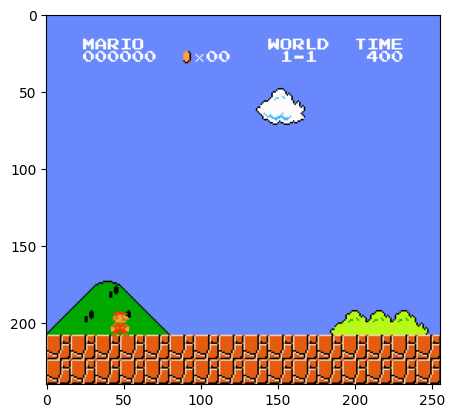

In [16]:
# Before Grayscaling
plt.imshow(state)

In [17]:
# 1. Create the base environment
env = gym_super_mario_bros.make('SuperMarioBros-v0')
# 2. Simplify the controls
env = JoypadSpace(env, SIMPLE_MOVEMENT)
# 3. Grayscale
env = GrayScaleObservation(env, keep_dim=True)
# 4. Wrap inside the Dummy Environment
env = DummyVecEnv([lambda: env])
# 5. Stack the frames
env =  VecFrameStack(env, 4, channels_order='last')

E:\Mario Game Using RL\.venv\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [18]:
state= env.reset()

In [19]:
SIMPLE_MOVEMENT

[['NOOP'],
 ['right'],
 ['right', 'A'],
 ['right', 'B'],
 ['right', 'A', 'B'],
 ['A'],
 ['left']]

In [20]:
state.shape

(1, 240, 256, 4)

In [21]:
# No. of pixels to process after grayscaling
# No. of pixels got cut by 1/3
240*256*1

61440

In [22]:
state, reward, done, info = env.step([5])

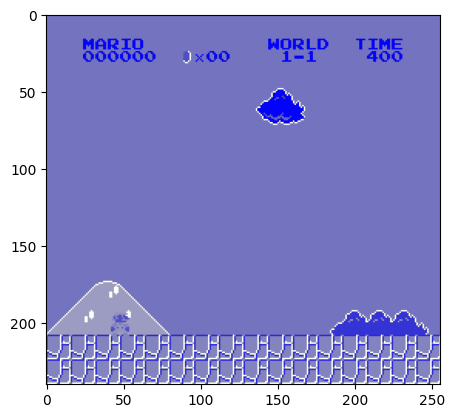

In [23]:
# After Grayscaling
plt.imshow(state[0])

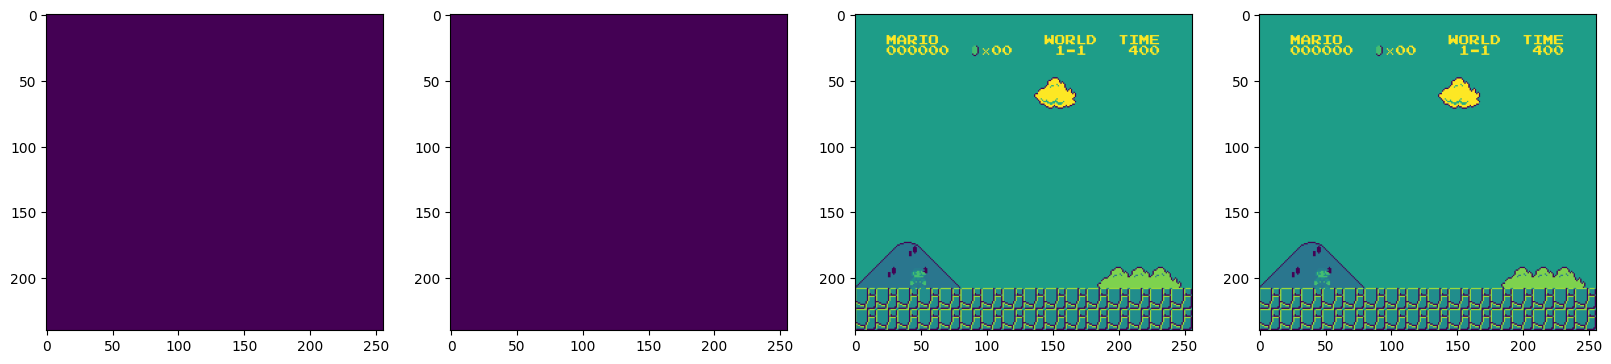

In [24]:
plt.figure(figsize=[20,16])
for idx in range(state.shape[3]):
    plt.subplot(1,4,idx+1)
    plt.imshow(state[0][:,:,idx])
plt.show()

## 3. Train the RL Model

In [25]:
# Import os for file path management
import os
# Import PPo for algos
from stable_baselines3 import PPO
# Import Base Callback for saving models
from stable_baselines3.common.callbacks import BaseCallback

In [26]:
class TrainAndLoggingCallback(BaseCallback):
    def __init__(self, check_freq,  save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [29]:
CHECKPOINT_DIR = './train/'
LOG_DIR = './logs/'

In [30]:
callback = TrainAndLoggingCallback(check_freq=10000, save_path=CHECKPOINT_DIR)

In [31]:
model = PPO('CnnPolicy', env, verbose=1, tensorboard_log=LOG_DIR, learning_rate=1e-6, n_steps = 512)

Using cuda device
Wrapping the env in a VecTransposeImage.


In [32]:
# Train the AI model, this is where the AI model starts to learn
model.learn(total_timesteps=1000000, callback=callback)

Logging to ./logs/PPO_1


E:\Mario Game Using RL\.venv\Lib\site-packages\gym_super_mario_bros\smb_env.py:148: RuntimeWarning: overflow encountered in scalar subtract
  return (self.ram[0x86] - self.ram[0x071c]) % 256


----------------------------
| time/              |     |
|    fps             | 202 |
|    iterations      | 1   |
|    time_elapsed    | 2   |
|    total_timesteps | 512 |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 152          |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 1.877232e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.95        |
|    explained_variance   | -0.00341     |
|    learning_rate        | 1e-06        |
|    loss                 | 146          |
|    n_updates            | 10           |
|    policy_gradient_loss | -5.11e-06    |
|    value_loss           | 348          |
------------------------------------------
-----------------------

In [34]:
model.save('thisisatestmodel')

## 4. Test it Out

In [27]:
# Load a model
model = PPO.load('./train/best_model_1000000')

In [28]:
state = env.reset()

In [31]:
SIMPLE_MOVEMENT[model.predict(state)[0][0]]

['right', 'A', 'B']

In [32]:
# ... imports ...

# Standard setup (No render_mode here)
env = gym_super_mario_bros.make('SuperMarioBros-v0')
env = JoypadSpace(env, SIMPLE_MOVEMENT)
env = GrayScaleObservation(env, keep_dim=True)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order='last')

model = PPO.load('./train/best_model_1000000')
state = env.reset()

while True:
    action, _ = model.predict(state)
    state, reward, done, info = env.step(action)

    # DIRECT ACCESS HACK
    # We bypass the SB3 compatibility layer and talk to the NES emulator directly
    env.venv.envs[0].env.unwrapped.render()

E:\Mario Game Using RL\.venv\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
E:\Mario Game Using RL\.venv\Lib\site-packages\gym_super_mario_bros\smb_env.py:148: RuntimeWarning: overflow encountered in scalar subtract
  return (self.ram[0x86] - self.ram[0x071c]) % 256


KeyboardInterrupt: 

In [33]:
env.close()